## Embedding Space Visualisation — Region 2 & Region 3

Dimensionality-reduced hidden-state embeddings at the critical adverb token (Region 2)
and mean-pooled over the spillover region (Region 3), comparing EN_Word_order vs FR_Word_order.

Each model is loaded **once**; embeddings are cached and reused for both the
summary table and the plots.

Grid layout per group figure:
```
         Region 2 (critical)          Region 3 (spillover)
         [mono]  |  [multi]           [mono]  |  [multi]
pair 1    ...         ...               ...        ...
pair 2    ...         ...               ...        ...
pair 3    ...         ...               ...        ...
pair 4    ...         ...               ...        ...
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from src.utils import (
    extract_embeddings,
    plot_group,
    separability_summary,
    MASKED_PAIRS,
    CAUSAL_PAIRS,
)

### Config

In [2]:
SAMPLE_FRAC = 1.0     # set to e.g. 0.2 for a quick test run
RANDOM_SEED = 42
METHOD      = "pca"   # "pca" | "tsne" | "umap"
LAYER       = -1      # transformer layer to extract (-1 = last layer)
REGIONS     = ["region2", "region3"]
SAVE_DIR    = "../results/embeddings"  # set to None to skip saving

full_df = pd.read_csv("../data/stimuli_generated.csv")

if SAMPLE_FRAC < 1.0:
    sampled_items = (
        full_df["item_no"]
        .drop_duplicates()
        .sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED)
    )
    df = full_df[full_df["item_no"].isin(sampled_items)].reset_index(drop=True)
else:
    df = full_df

print(f"Items : {df['item_no'].nunique()}  |  Rows : {len(df)}  |  Method : {METHOD.upper()}")

Items : 180  |  Rows : 360  |  Method : PCA


### Extract all embeddings

Each unique model is loaded once and immediately unloaded.
Both Region 2 and Region 3 are extracted in the same forward pass.

In [3]:
def extract_all(pairs, model_type):
    """
    Returns nested dict: {region: {model_key: emb_df}}
    Each unique model is loaded only once across all pairs.
    """
    unique_keys = dict.fromkeys(k for pair in pairs for k in pair)
    per_model   = {
        key: extract_embeddings(df, key, model_type=model_type,
                                regions=REGIONS, layer=LAYER)
        for key in unique_keys
    }
    # Reshape: {region: {model_key: emb_df}}
    return {
        region: {key: per_model[key][region] for key in unique_keys}
        for region in REGIONS
    }

print("=== Masked LMs ===")
masked_embs = extract_all(MASKED_PAIRS, "masked")

print("\n=== Causal LMs ===")
causal_embs = extract_all(CAUSAL_PAIRS, "causal")

print("\nAll embeddings extracted.")

=== Masked LMs ===
  Loading roberta (roberta-base) on mps …


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Loading xlmr (xlm-roberta-base) on mps …


...

  Loading bloom-560m (bigscience/bloom-560m) on mps …


Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

  Loading pythia-160m (EleutherAI/pythia-160m) on mps …


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


All embeddings extracted.


### Cosine distance summary

Mean cosine distance between paired EN / FR embeddings per model and region.
Expected: multilingual (✓) < monolingual (ref) within each pair.

In [4]:
summary_masked = separability_summary(masked_embs, MASKED_PAIRS, REGIONS)
summary_causal = separability_summary(causal_embs, CAUSAL_PAIRS, REGIONS)

print("=== Masked LMs ===")
display(summary_masked)
print("\n=== Causal LMs ===")
display(summary_causal)

=== Masked LMs ===


,pair,region,model,is_multilingual,d_prime,direction
0,roberta → xlmr,region2,roberta,False,10.6105,(ref)
1,roberta → xlmr,region2,xlmr,True,3.5924,✓
2,roberta → xlmr,region3,roberta,False,3.4655,(ref)
3,roberta → xlmr,region3,xlmr,True,1.3168,✓
4,bert → mbert,region2,bert,False,6.0894,(ref)
5,bert → mbert,region2,mbert,True,4.8729,✓
6,bert → mbert,region3,bert,False,2.0527,(ref)
7,bert → mbert,region3,mbert,True,1.5743,✓
8,distilbert → distilmbert,region2,distilbert,False,7.3616,(ref)
9,distilbert → distilmbert,region2,distilmbert,True,4.4465,✓



=== Causal LMs ===


,pair,region,model,is_multilingual,d_prime,direction
0,gpt2 → mgpt,region2,gpt2,False,14.5309,(ref)
1,gpt2 → mgpt,region2,mgpt,True,11.4332,✓
2,gpt2 → mgpt,region3,gpt2,False,3.5945,(ref)
3,gpt2 → mgpt,region3,mgpt,True,1.9820,✓
4,gpt2 → croissantllm,region2,gpt2,False,14.5309,(ref)
5,gpt2 → croissantllm,region2,croissantllm,True,8.6158,✓
6,gpt2 → croissantllm,region3,gpt2,False,3.5945,(ref)
7,gpt2 → croissantllm,region3,croissantllm,True,2.7125,✓
8,opt-125m → bloom-560m,region2,opt-125m,False,1.6300,(ref)
9,opt-125m → bloom-560m,region2,bloom-560m,True,7.6073,✗


### Masked LMs — all 4 pairs × Region 2 & 3

Saved → ../results/embeddings/masked_pca.png


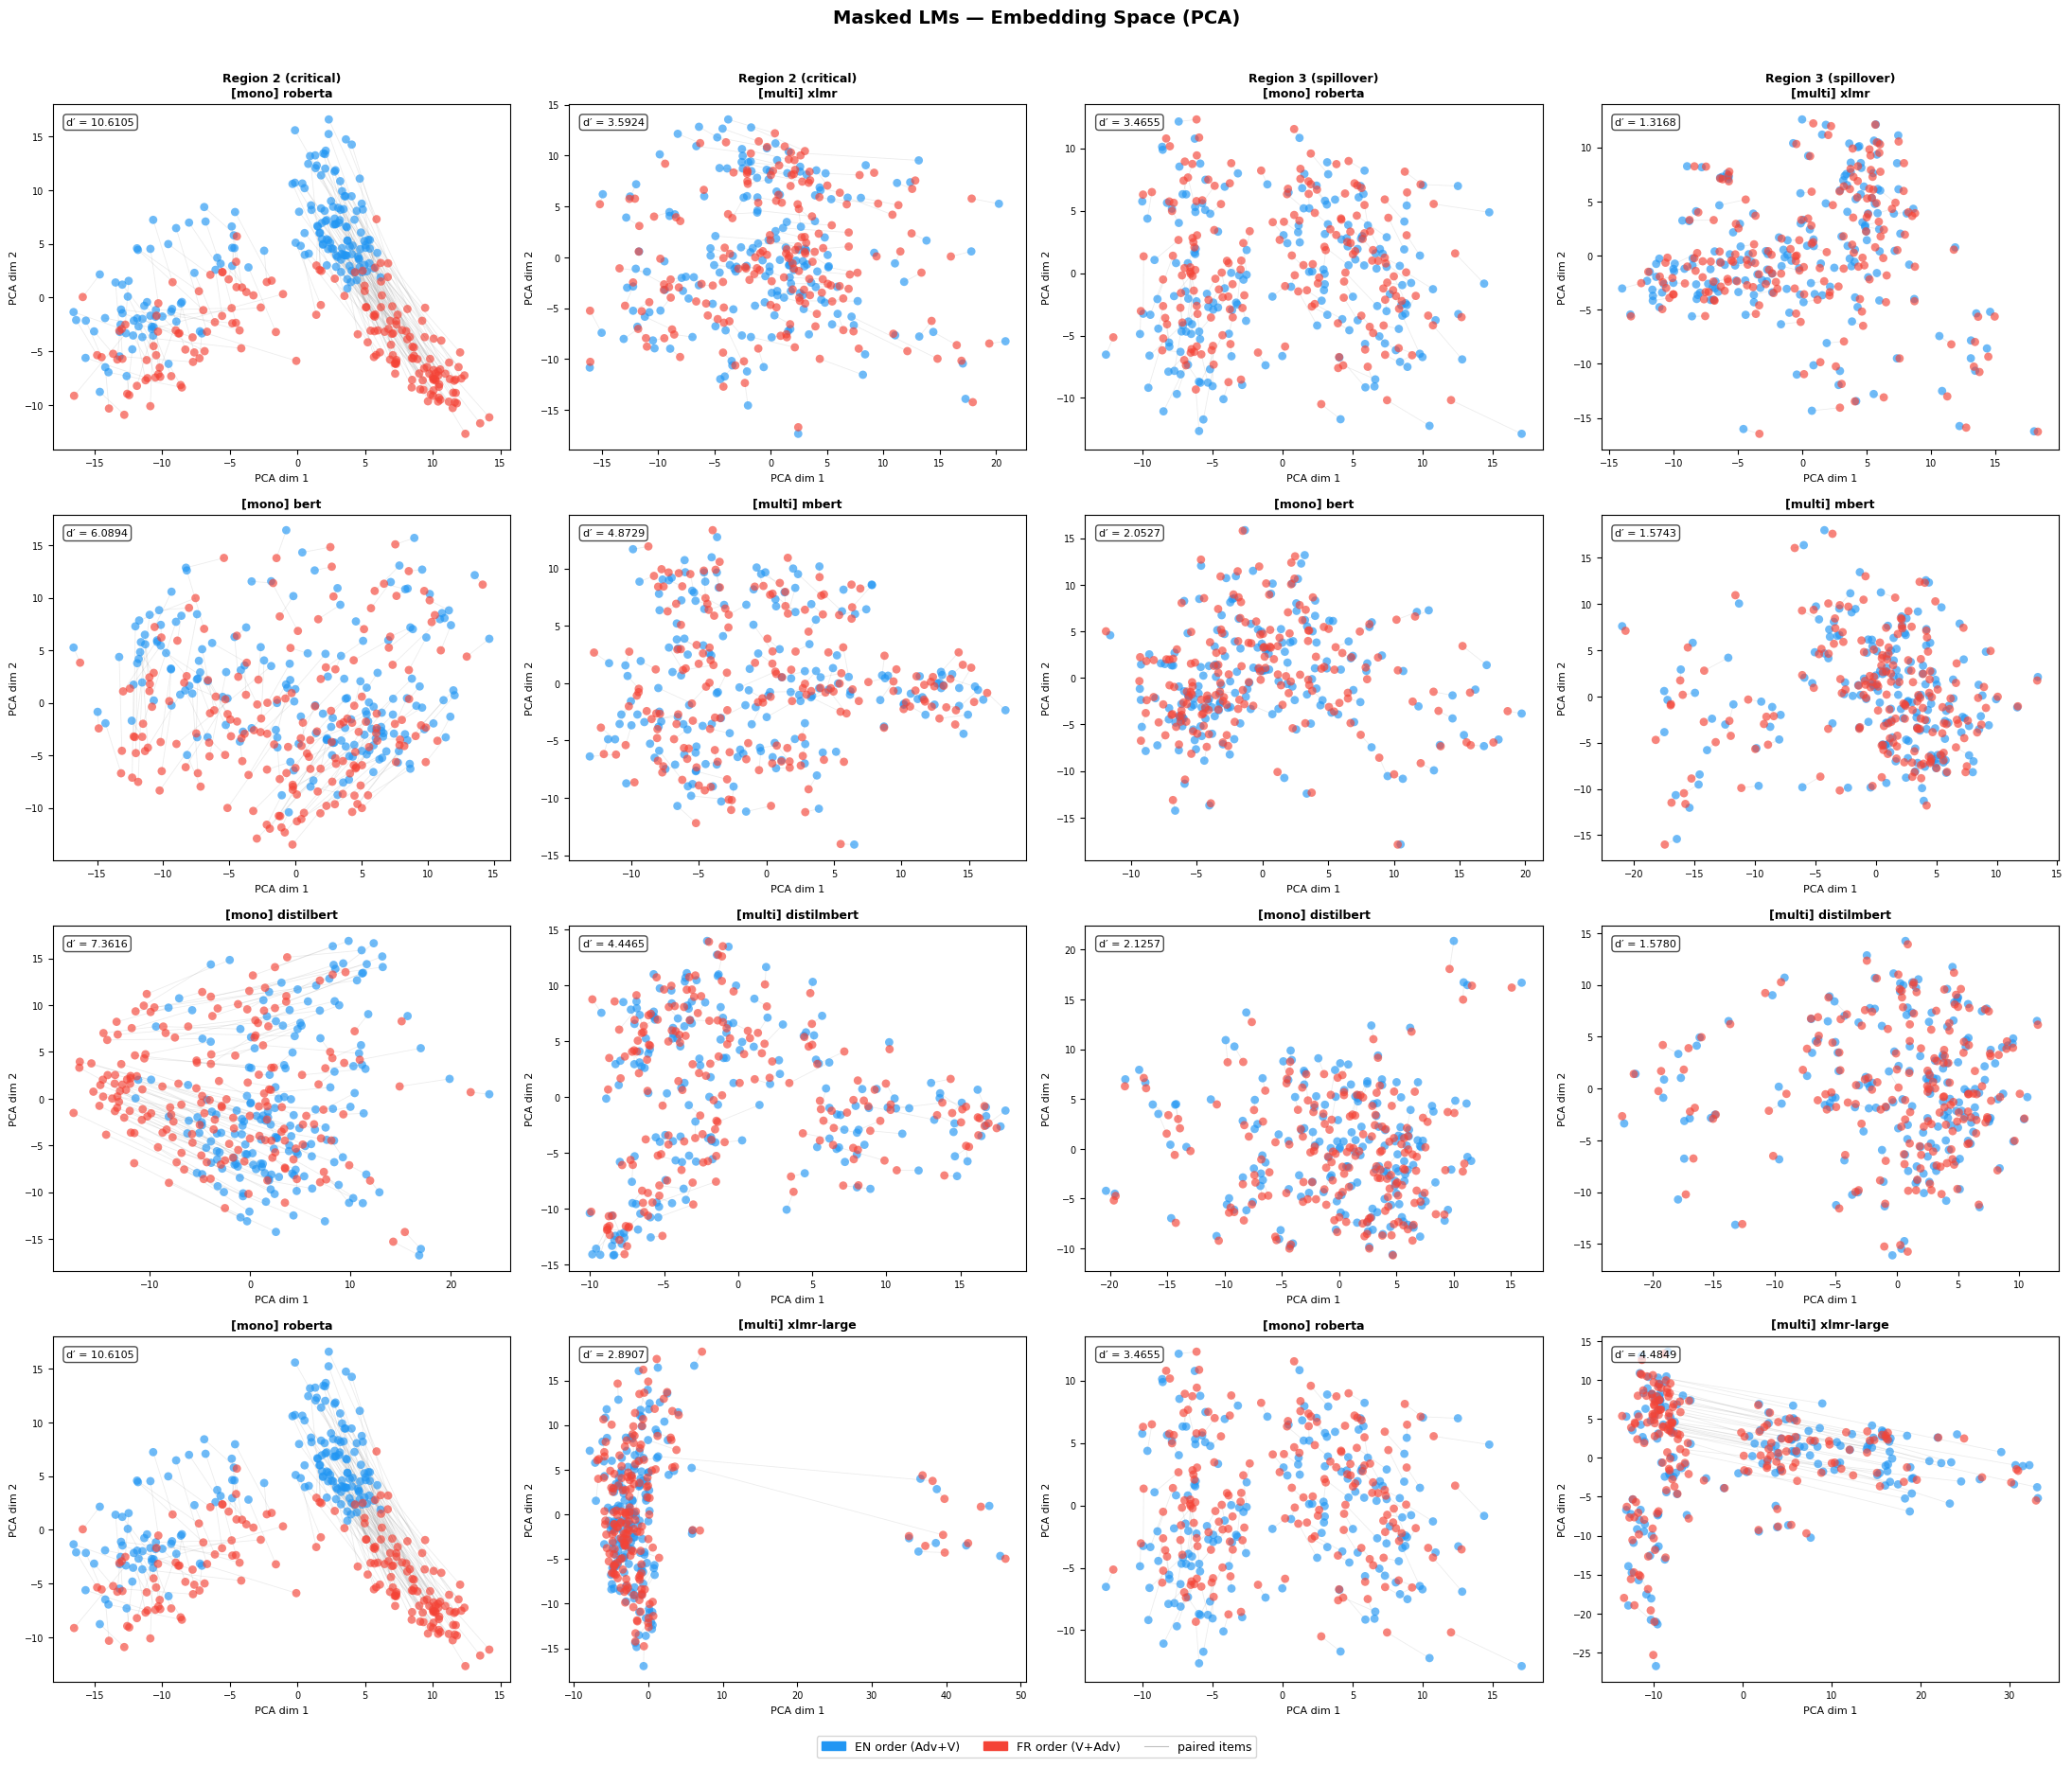

In [5]:
fig_masked = plot_group(
    masked_embs, MASKED_PAIRS, REGIONS,
    group_title="Masked LMs",
    method=METHOD,
    save_dir=SAVE_DIR,
    save_name=f"masked_{METHOD}.png",
)
plt.show()

### Causal LMs — all 4 pairs × Region 2 & 3

Saved → ../results/embeddings/causal_pca.png


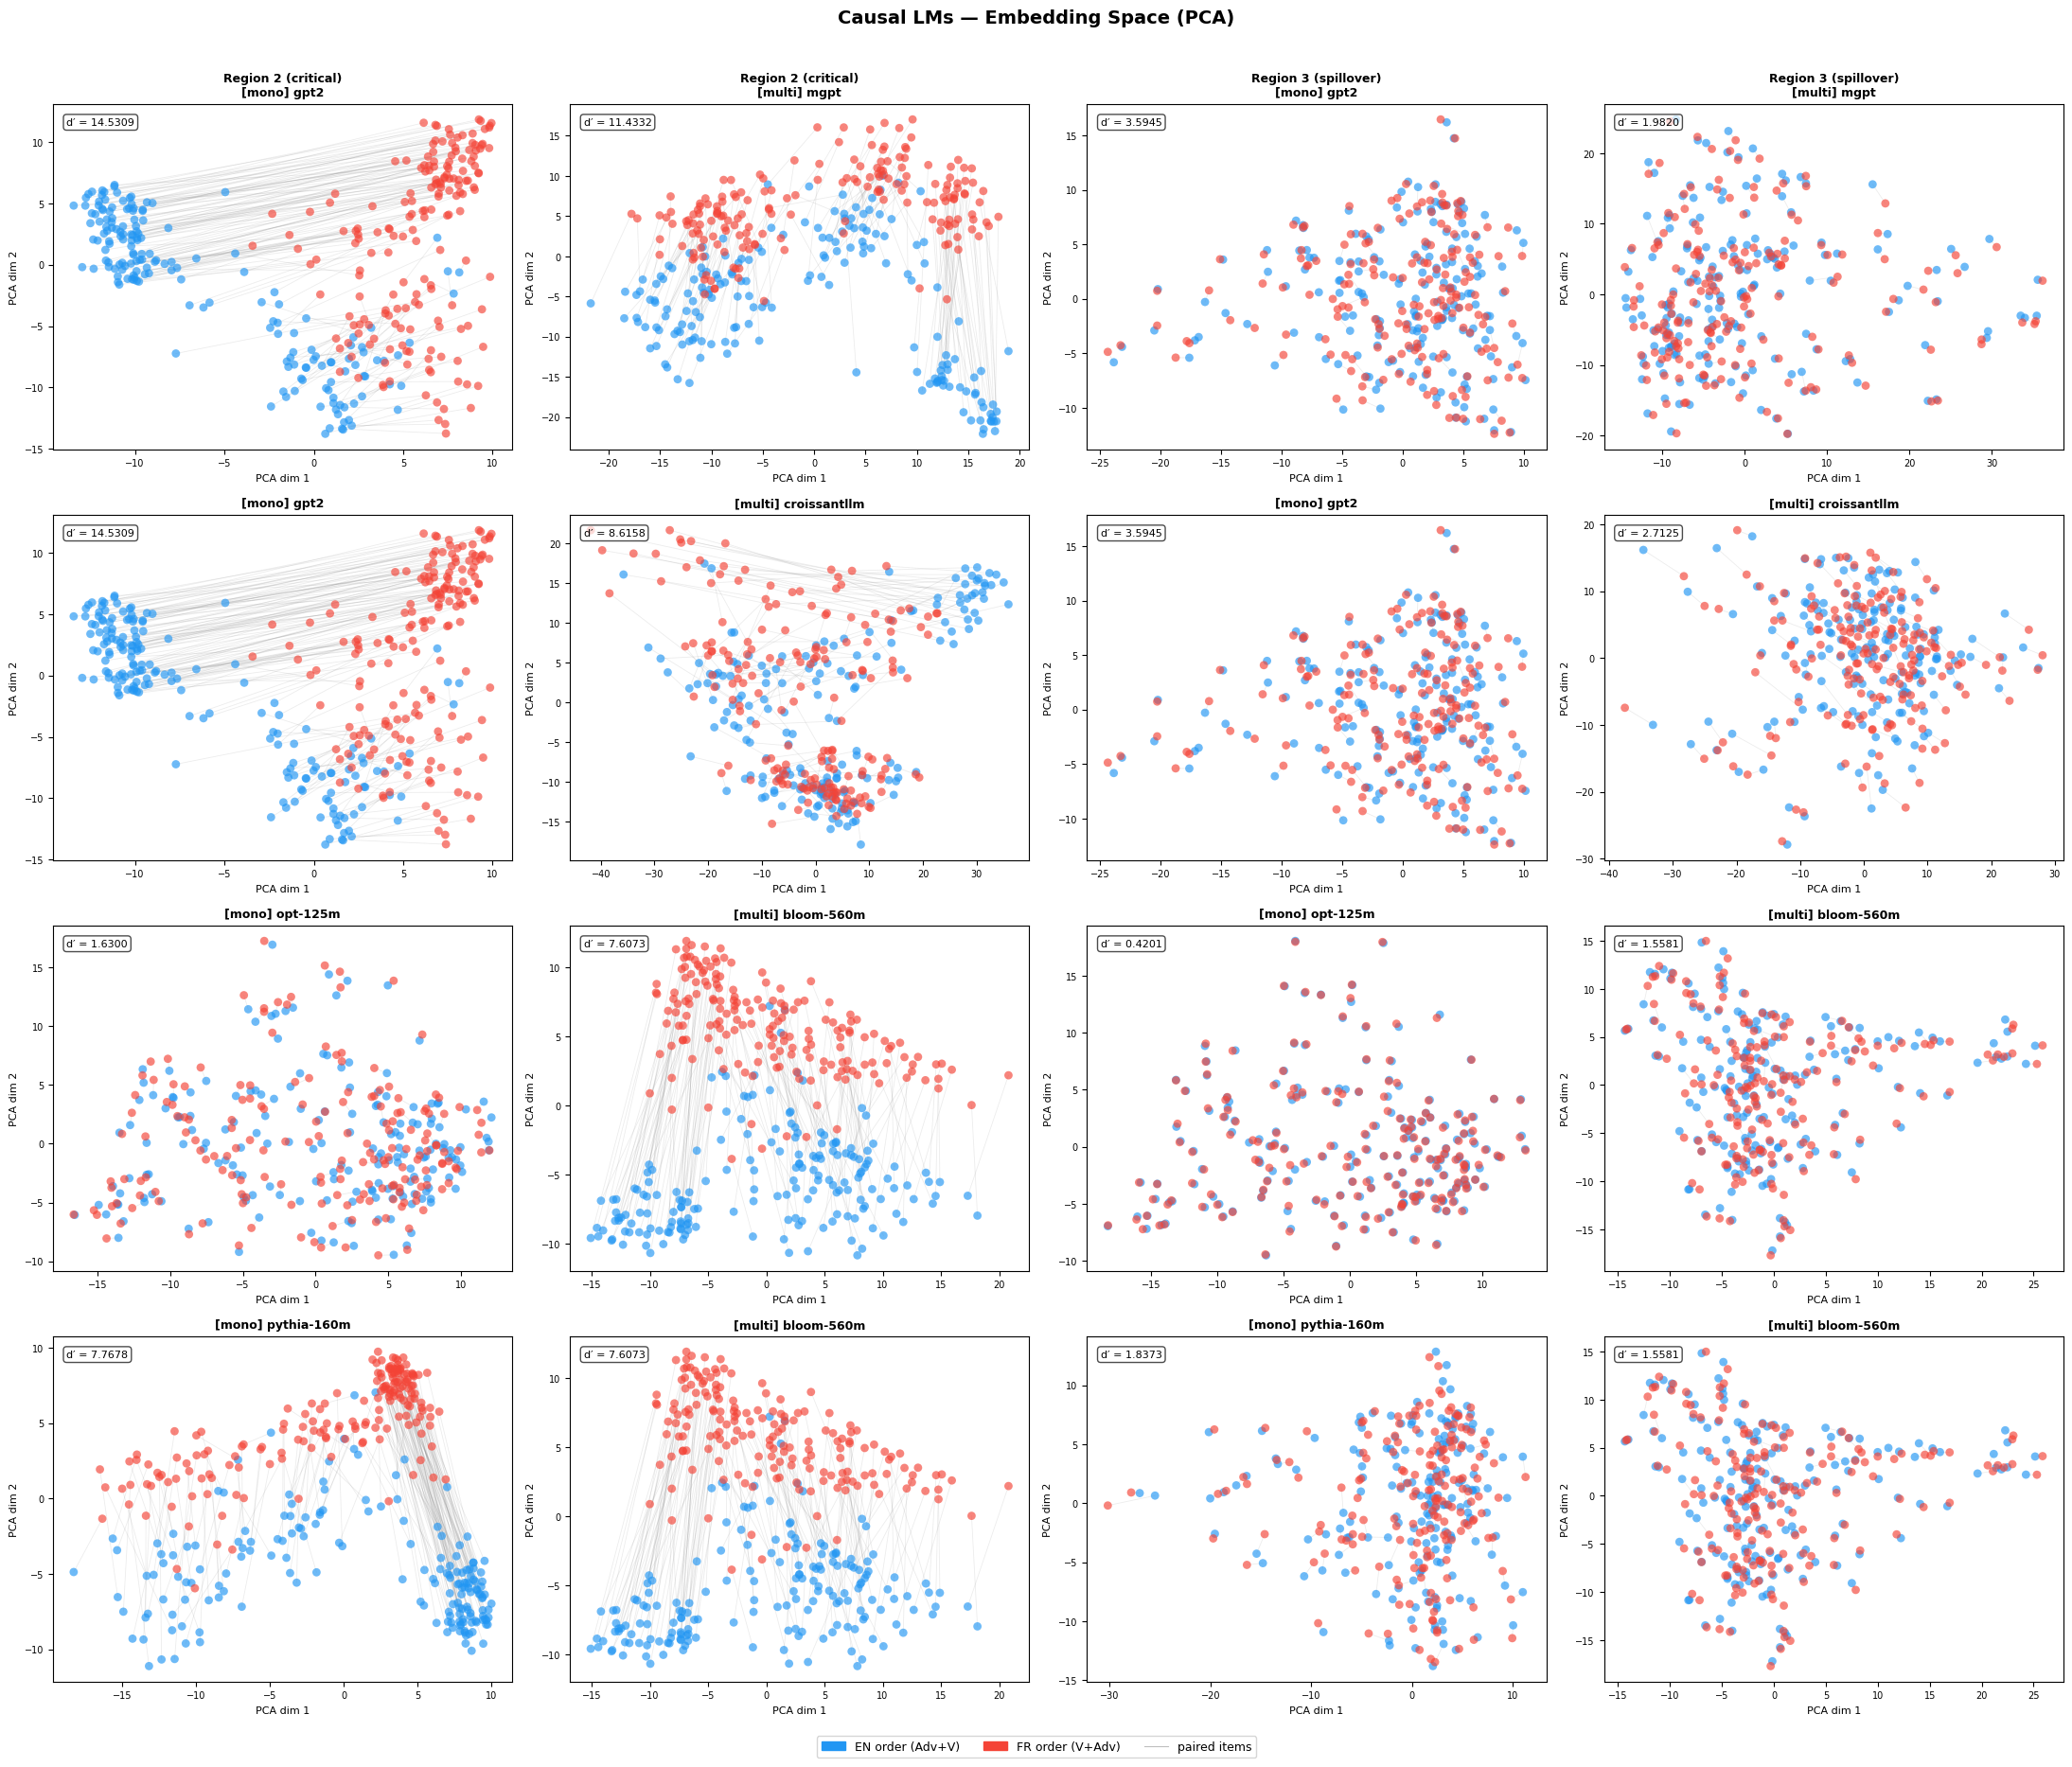

In [6]:
fig_causal = plot_group(
    causal_embs, CAUSAL_PAIRS, REGIONS,
    group_title="Causal LMs",
    method=METHOD,
    save_dir=SAVE_DIR,
    save_name=f"causal_{METHOD}.png",
)
plt.show()